<a href="https://colab.research.google.com/github/nicolenelson10/credit-card-fraud-detection-ml/blob/feature%2Flogistic-regression/notebooks/02_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print(os.listdir("dataset"))

['creditcard.csv']


In [3]:
import pandas as pd

df = pd.read_csv("dataset/creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (227845, 30)
Testing set: (56962, 30)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])

# Use the same scaler to transform test data
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

print("Amount scaling completed!")

Amount scaling completed!


In [9]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [10]:
# Make predictions on the test set

y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.9754924335521927
Precision: 0.06089309878213803
Recall   : 0.9183673469387755
F1-Score : 0.11421319796954314


In [12]:
print("===== LOGISTIC REGRESSION RESULTS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

===== LOGISTIC REGRESSION RESULTS =====
Accuracy : 0.9755
Precision: 0.0609
Recall   : 0.9184
F1-Score : 0.1142


In [13]:
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[55476  1388]
 [    8    90]]


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

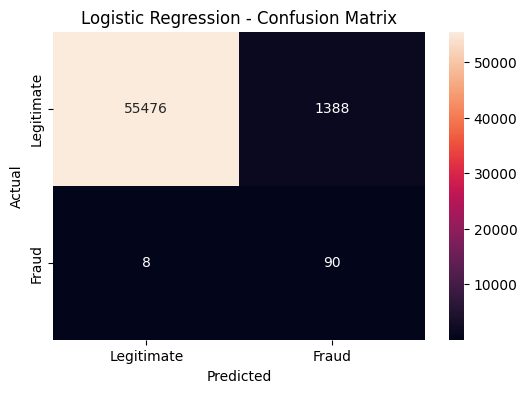

In [16]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## Interpretation of Logistic Regression Results

The Logistic Regression model achieved an accuracy of 97.55%. However, because the dataset is highly imbalanced, accuracy alone does not provide a complete picture of model performance.

The model achieved a recall of 91.84%, meaning that it detected most of the fraudulent transactions. However, its precision was only 6.09%, indicating that many transactions predicted as fraudulent were actually legitimate.

The confusion matrix showed:
- True Positives (TP): 90
- True Negatives (TN): 55,476
- False Positives (FP): 1,388
- False Negatives (FN): 8

This demonstrates that precision, recall, F1-score, and confusion matrix are more meaningful evaluation metrics than accuracy alone in fraud detection problems with severe class imbalance.